# Permutation Puzzles
## Cycles, parity, and Cayley's theorem, built from scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/courses/blob/main/2026fall/mat4233/downloads/public/activities/permutation-puzzles.ipynb)
[![License: CC BY 4.0](https://img.shields.io/badge/License-CC%20BY%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by/4.0/)

---

Every finite group secretly lives inside a group of permutations — that's
Cayley's theorem, and it's one of the most concrete facts in group theory:
you can *see* it, not just prove it. This notebook builds permutations as
plain functions, uses them to construct the alternating group $A_4$ (the
rotational symmetries of a tetrahedron), and ends with the classical fact
that only *half* of all 15-puzzle scrambles are solvable — a genuinely
surprising consequence of a permutation's **parity**.

1. **Permutations as functions** — composing, inverting, and reading off
   cycle notation and sign, all in a dozen lines of code.
2. **$A_4$: the even permutations of 4 points** — built by brute force,
   checked for closure, then drawn as a Cayley graph.
3. **Cayley's theorem, concretely** — embedding a 4-element group into
   $S_4$ by having each element act on the group itself.
4. **Bonus: the 15-puzzle** — why a single tile swap breaks solvability.

Nothing here has a grade attached and there's nothing to submit. Tinker
freely — *Runtime → Run all* always resets you to a clean state.


---
# 0. Setup


In [1]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx


---
# 1. Permutations as functions

A permutation of $\{0, 1, \dots, n-1\}$ is just a bijection from that set
to itself. We represent one as a tuple `p` where `p[i]` is where `i` goes.
Composing two permutations is composing two functions — nothing more.


In [2]:
def compose(p, q):
    """(p after q): apply q first, then p."""
    return tuple(p[q[i]] for i in range(len(p)))

def identity(n):
    return tuple(range(n))

def inverse(p):
    inv = [0] * len(p)
    for i, v in enumerate(p):
        inv[v] = i
    return tuple(inv)

def cycle_decomposition(p):
    n = len(p)
    seen = [False] * n
    cycles = []
    for i in range(n):
        if seen[i]:
            continue
        cyc = []
        j = i
        while not seen[j]:
            seen[j] = True
            cyc.append(j)
            j = p[j]
        if len(cyc) > 1:
            cycles.append(tuple(cyc))
    return cycles

def cycle_notation(p):
    cycles = cycle_decomposition(p)
    if not cycles:
        return "e"
    return "".join("(" + " ".join(str(x) for x in c) + ")" for c in cycles)

def sign(p):
    """+1 if p is a product of an even number of transpositions, else -1."""
    transpositions = sum(len(c) - 1 for c in cycle_decomposition(p))
    return -1 if transpositions % 2 else 1

p = (1, 2, 0, 3)   # sends 0->1, 1->2, 2->0, 3->3
q = (1, 0, 3, 2)
print("p =", cycle_notation(p), " sign(p) =", sign(p))
print("q =", cycle_notation(q), " sign(q) =", sign(q))
print("p then q =", cycle_notation(compose(q, p)))
print("p then p^-1 =", cycle_notation(compose(p, inverse(p))), "(should be e)")


p = (0 1 2)  sign(p) = 1
q = (0 1)(2 3)  sign(q) = 1
p then q = (1 3 2)
p then p^-1 = e (should be e)


**Try it:** pick your own `p` (any tuple that's a rearrangement of
`0, 1, 2, 3`) and predict its cycle notation and sign *before* running the
cell again. A 3-cycle like `(0 1 2)` always has sign $+1$ — can you see why,
just from the definition of sign above?


---
# 2. $A_4$: the even permutations of 4 points

Label the 4 vertices of a tetrahedron $0, 1, 2, 3$. Every rotation of the
solid permutes these labels, and the rotations form a group of order 12 —
exactly the *even* permutations of $\{0,1,2,3\}$, called $A_4$. We don't
need the physical solid to study this: we can build $A_4$ directly as a
subset of all 24 permutations of 4 points.


In [3]:
S4 = list(itertools.permutations(range(4)))
A4 = [p for p in S4 if sign(p) == 1]
print("S4 has", len(S4), "elements; A4 has", len(A4))

# closure check: is every product of two elements of A4 still in A4?
A4_set = set(A4)
closed = all(compose(p, q) in A4_set for p in A4 for q in A4)
print("A4 closed under composition:", closed)


S4 has 24 elements; A4 has 12
A4 closed under composition: True


**Before running the next cell:** $A_4$ is generated by a 3-cycle and a
double-transposition. Do you expect its Cayley graph to look more like
ℤ₁₂ (a single loop) or more like D4 (two linked rings)? $A_4$ has 12
elements but is *not* cyclic and *not* dihedral — so neither, necessarily.


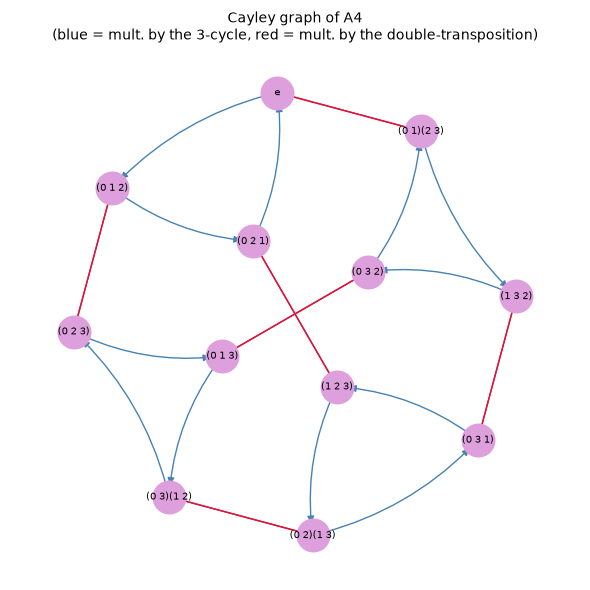

In [4]:
g1 = (1, 2, 0, 3)   # the 3-cycle (0 1 2)
g2 = (1, 0, 3, 2)   # the double-transposition (0 1)(2 3)

G = nx.MultiDiGraph()
labels = {p: cycle_notation(p) for p in A4}
G.add_nodes_from(A4)
for p in A4:
    G.add_edge(p, compose(p, g1), gen="g1")
    G.add_edge(p, compose(p, g2), gen="g2")

# kamada_kawai gives the nicest picture of this graph but needs SciPy, which
# Colab has and a bare local Python may not. Fall back rather than crash: the
# notebook has to work anywhere it is opened.
try:
    pos = nx.kamada_kawai_layout(G)
except ImportError:
    pos = nx.spring_layout(G, seed=3)
fig, ax = plt.subplots(figsize=(6, 6))
edges_g1 = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "g1"]
edges_g2 = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "g2"]
nx.draw_networkx_nodes(G, pos, node_color="plum", ax=ax, node_size=550)
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7)
nx.draw_networkx_edges(G, pos, edgelist=edges_g1, edge_color="steelblue", ax=ax,
                        connectionstyle="arc3,rad=0.15", arrows=True, arrowsize=10)
nx.draw_networkx_edges(G, pos, edgelist=edges_g2, edge_color="crimson", ax=ax,
                        arrows=False, width=1.0)
ax.set_title("Cayley graph of A4\n(blue = mult. by the 3-cycle, red = mult. by the double-transposition)",
             fontsize=10)
ax.axis("equal"); ax.axis("off")
plt.tight_layout()
plt.show()


Notice every red edge is a matched pair (undirected), just like D4's
reflection edges — for the same reason: the double-transposition `g2` is
its own inverse. The blue 3-cycle edges, on the other hand, only ever come
in one direction, and always in triples (since `g1` has order 3): find one
of those triangles in the picture.


---
# 3. Cayley's theorem, concretely

**Cayley's theorem** says every group of order $n$ is (isomorphic to) a
subgroup of $S_n$: every abstract group secretly *is* a permutation group.
The construction: let each element $g$ act on the group's own elements by
left multiplication, $x \mapsto g \cdot x$. Since left multiplication by
$g$ is always a bijection, this gives a permutation of the group for every
$g$ — and composing two such permutations exactly matches multiplying the
corresponding elements.

We check this concretely for the Klein four-group $V_4 = \mathbb{Z}_2 \times
\mathbb{Z}_2$, acting on its own 4 elements.


In [5]:
V4 = list(itertools.product([0, 1], repeat=2))

def v4_add(a, b):
    return ((a[0] + b[0]) % 2, (a[1] + b[1]) % 2)

index_of = {v: i for i, v in enumerate(V4)}

def left_mult_perm(g):
    """The permutation of {0,1,2,3} (V4's own elements, in list order)
    induced by left-multiplying every element by g."""
    return tuple(index_of[v4_add(g, v)] for v in V4)

perms = {g: left_mult_perm(g) for g in V4}
for g in V4:
    print(g, "acts as", cycle_notation(perms[g]))

# the embedding must be a homomorphism: perm(g) then perm(h) == perm(g+h)
matches = all(compose(perms[g], perms[h]) == perms[v4_add(g, h)]
              for g in V4 for h in V4)
print("composition matches the group operation for every pair:", matches)
print("all four permutations are distinct (the embedding is faithful):",
      len(set(perms.values())) == 4)


(0, 0) acts as e
(0, 1) acts as (0 1)(2 3)
(1, 0) acts as (0 2)(1 3)
(1, 1) acts as (0 3)(1 2)
composition matches the group operation for every pair: True
all four permutations are distinct (the embedding is faithful): True


That's Cayley's theorem, checked by brute force on one small example: $V_4$
(an abstract group defined purely by an addition rule) turns out to *be* a
specific subgroup of $S_4$, namely `{e, (0 1)(2 3), (0 2)(1 3), (0 3)(1 2)}`
— which you may recognize from Section 2's picture.


---
# 4. Bonus: the 15-puzzle and the sign of a permutation

The classic 4×4 sliding puzzle has one blank cell and 15 numbered tiles.
A *slide* swaps the blank with one adjacent tile — in permutation language,
a single transposition of two positions. Every transposition flips the sign
of a permutation (from the definition in Section 1: it changes the
transposition count by exactly one). Since the solved state has sign $+1$
(it's the identity), **every reachable configuration is reachable in a
number of slides whose parity is fixed by how far the blank has moved** —
this is the heart of the classical theorem that *exactly half* of the
$16!/2$ configurations with the blank in a given cell are actually solvable.

You don't need 16 tiles to see the key fact — just that composing with a
transposition always flips sign, no matter how many times you do it:


In [6]:
import random
random.seed(0)

def random_transposition(n):
    i, j = random.sample(range(n), 2)
    p = list(identity(n))
    p[i], p[j] = p[j], p[i]
    return tuple(p)

n = 8
current = identity(n)
history = [sign(current)]
for _ in range(20):
    t = random_transposition(n)
    current = compose(t, current)
    history.append(sign(current))

print("sign after each of 20 random slides:")
print(history)
flips = sum(1 for a, b in zip(history, history[1:]) if a != b)
print(f"the sign flipped on all {flips} of the 20 slides (it always does)")


sign after each of 20 random slides:
[1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1]
the sign flipped on all 20 of the 20 slides (it always does)


**Exercise (no code needed):** if the 15-puzzle's blank returns to its
starting square after some sequence of slides, argue that the number of
slides must be *even*. Combine that with "every slide flips sign" to explain
why swapping just two tiles (leaving the blank exactly where it started)
can never be reached by sliding, no matter how patient you are.


---
# 5. Summary

- A permutation's cycle decomposition and sign are computable from the
  definition alone — no lookup table needed, and they compose predictably
  ($\mathrm{sign}(p \circ q) = \mathrm{sign}(p)\,\mathrm{sign}(q)$).
- $A_4$, the rotations of a tetrahedron, is exactly the even permutations of
  4 labeled points — a genuinely non-abelian, non-cyclic, non-dihedral group
  of order 12.
- Cayley's theorem isn't just an existence statement: for any specific small
  group, you can write down its embedding into a symmetric group by hand.
- Parity (sign) is a homomorphism from any symmetric group to $\{\pm 1\}$,
  and that one fact is the entire reason half of all 15-puzzle scrambles are
  unsolvable.


---
# 6. Exercises

1. **Order of an element.** Write a function that computes the order of a
   permutation (the smallest $k$ with $p^k = e$) from its cycle lengths
   (hint: it's the lcm of the cycle lengths). Verify it against `g1` and
   `g2` from Section 2.
2. **$S_4$ minus $A_4$.** Plot the Cayley graph of all of $S_4$ (24 elements,
   same two generators). Is it connected? What role does $A_4$ play inside
   the picture?
3. **A different embedding.** Section 3 embeds $V_4$ into $S_4$. Do the same
   for $\mathbb{Z}_4$ (cyclic of order 4) using left multiplication, and
   compare the cycle types you get to $V_4$'s. Why must a cyclic group's
   regular representation consist of permutations that are single 4-cycles
   (or the identity), never anything else?
4. **The 8-puzzle.** The 3×3 version of the sliding puzzle has $9!/2$
   solvable configurations out of $9!$ total. Using only the parity
   argument above (not a full search), explain why the fraction is exactly
   $1/2$ regardless of the grid size.


---
## License

This notebook is released under the [Creative Commons Attribution 4.0
International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/). You are free to copy, adapt,
and redistribute it, including for commercial purposes, provided you give
appropriate credit.

Suggested attribution: *"Permutation Puzzles" by [Eduardo Dueñez](https://supernumero.us/about),
licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*
